# Pareto conditional analysis — 2026-08-04

**Data:** `pareto_results_jul_10000samples/pareto_results.csv` (10,000 independent
log-uniform samples over the 5 objective weights; `fraction_kinetic_target` fixed
at 1.0, no baseline knockdown applied).

For each of the 5 raw lambda weights and all 10 pairwise log-ratios between them,
this notebook computes:
- Random Forest feature importance for predicting `toya_r_squared` and `obj_homeo`
- Pearson correlation with each target
- Scatter plots of each feature against each target, titled with its Pearson r and
  sorted by \|r\| (most correlated panel first)

Goal: identify which weights/ratios matter most for (a) a good Toya central-carbon
flux fit and (b) a low homeostatic penalty, and where the two are in tension.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.ensemble import RandomForestRegressor

## Load data

In [32]:
PARETO_DIR = "pareto_results_relationship_sep_v3_10000samples"
CSV_PATH = f"{PARETO_DIR}/pareto_results.csv"

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows from {CSV_PATH}")
print(f"fraction_kinetic_target unique values: {df['fraction_kinetic_target'].unique()}")
df.head()

Loaded 10,000 rows from pareto_results_relationship_sep_v3_10000samples/pareto_results.csv
fraction_kinetic_target unique values: [1.]


,lambda_hom,lambda_sec,lambda_eff,lambda_kin,lambda_div,fraction_kinetic_target,obj_total,obj_homeo,obj_kin,obj_eff,obj_sec,obj_div,obj_hom_w,obj_kin_w,obj_eff_w,obj_sec_w,obj_div_w,toya_pearson_r_squared,toya_r_squared
0,0.993053,0.001973,2.974944e-06,0.001471,0.000466,1.0,0.039718,3.950755e-12,23.022082,155.055212,2.733865,0.002295,3.923310e-12,0.033863,0.000461,0.005393,1.068216e-06,0.738258,0.541653
1,1.239987,0.003048,2.908524e-05,0.001774,0.000512,1.0,0.053637,4.704726e-04,23.157600,143.597517,2.555061,0.002325,5.833801e-04,0.041088,0.004177,0.007788,1.189367e-06,0.713061,0.578262
2,0.179718,0.000427,7.775100e-07,0.000294,0.000173,1.0,0.008060,5.455522e-05,23.007996,154.896914,2.720811,0.002190,9.804554e-06,0.006768,0.000120,0.001162,3.789460e-07,0.738025,0.545326
3,0.100001,0.000238,3.735294e-07,0.000149,0.000012,1.0,0.004127,3.433938e-12,23.022092,155.054885,2.733843,0.002438,3.433982e-13,0.003419,0.000058,0.000650,2.981397e-08,0.738258,0.541656
4,0.195024,0.000402,2.291952e-07,0.000288,0.000011,1.0,0.007758,2.196066e-12,23.022090,155.054814,2.733842,0.002495,4.282860e-13,0.006623,0.000036,0.001099,2.749404e-08,0.739216,0.541997


## Log-transform weights and compute pairwise ratios

All analysis is done in log10 space, since the lambdas are sampled log-uniformly
across several orders of magnitude. Each ratio `ratio_<a>_<b>` is
`log10(lambda_a) - log10(lambda_b) = log10(lambda_a / lambda_b)`.
`obj_homeo` is also log-transformed (`log_obj_homeo`) since it spans roughly 13
orders of magnitude across samples.

In [33]:
LAMBDA_COLS = ["lambda_hom", "lambda_sec", "lambda_eff", "lambda_kin", "lambda_div"]
SHORT = {"lambda_hom": "hom", "lambda_sec": "sec", "lambda_eff": "eff",
         "lambda_kin": "kin", "lambda_div": "div"}

for c in LAMBDA_COLS:
    df[f"log_{c}"] = np.log10(df[c])
WEIGHT_FEATURES = [f"log_{c}" for c in LAMBDA_COLS]

RATIO_FEATURES = []
for a, b in combinations(LAMBDA_COLS, 2):
    name = f"ratio_{SHORT[a]}_{SHORT[b]}"
    df[name] = df[f"log_{a}"] - df[f"log_{b}"]
    RATIO_FEATURES.append(name)

df["log_obj_homeo"] = np.log10(df["obj_homeo"].clip(lower=1e-16))

print(f"{len(WEIGHT_FEATURES)} weight features: {WEIGHT_FEATURES}")
print(f"{len(RATIO_FEATURES)} ratio features: {RATIO_FEATURES}")

5 weight features: ['log_lambda_hom', 'log_lambda_sec', 'log_lambda_eff', 'log_lambda_kin', 'log_lambda_div']
10 ratio features: ['ratio_hom_sec', 'ratio_hom_eff', 'ratio_hom_kin', 'ratio_hom_div', 'ratio_sec_eff', 'ratio_sec_kin', 'ratio_sec_div', 'ratio_eff_kin', 'ratio_eff_div', 'ratio_kin_div']


## Random Forest importance

Fits a Random Forest regressor per (feature set, target) pair and reports feature
importances. Weight and ratio features are fit separately so ratio importance
isn't diluted by the (largely redundant) raw weights.

In [34]:
def rf_importance(features, target, label=None, **rf_kwargs):
    """Fit a RandomForestRegressor(features -> target) and return sorted importances."""
    X = df[features].values
    y = df[target].values
    rf = RandomForestRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=5,
        random_state=0, n_jobs=-1, **rf_kwargs,
    )
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
    print(f"--- {label or target} (R2={rf.score(X, y):.3f}, n_features={len(features)}) ---")
    for feat, imp in importances.items():
        print(f"  {feat:<15} {imp:.3f}")
    print()
    return importances


toya_weight_imp = rf_importance(WEIGHT_FEATURES, "toya_r_squared", "weights -> toya_r_squared")
toya_ratio_imp = rf_importance(RATIO_FEATURES, "toya_r_squared", "ratios -> toya_r_squared")
homeo_weight_imp = rf_importance(WEIGHT_FEATURES, "log_obj_homeo", "weights -> log_obj_homeo")
homeo_ratio_imp = rf_importance(RATIO_FEATURES, "log_obj_homeo", "ratios -> log_obj_homeo")

--- weights -> toya_r_squared (R2=0.591, n_features=5) ---
  log_lambda_sec  0.479
  log_lambda_kin  0.323
  log_lambda_eff  0.102
  log_lambda_hom  0.078
  log_lambda_div  0.019

--- ratios -> toya_r_squared (R2=0.993, n_features=10) ---
  ratio_sec_kin   0.718
  ratio_eff_kin   0.202
  ratio_hom_eff   0.056
  ratio_sec_eff   0.019
  ratio_hom_sec   0.005
  ratio_eff_div   0.000
  ratio_hom_kin   0.000
  ratio_hom_div   0.000
  ratio_kin_div   0.000
  ratio_sec_div   0.000

--- weights -> log_obj_homeo (R2=0.399, n_features=5) ---
  log_lambda_sec  0.484
  log_lambda_hom  0.429
  log_lambda_eff  0.062
  log_lambda_kin  0.019
  log_lambda_div  0.006

--- ratios -> log_obj_homeo (R2=0.984, n_features=10) ---
  ratio_hom_sec   0.789
  ratio_hom_eff   0.088
  ratio_hom_kin   0.080
  ratio_eff_kin   0.023
  ratio_sec_eff   0.012
  ratio_sec_kin   0.005
  ratio_eff_div   0.001
  ratio_kin_div   0.001
  ratio_sec_div   0.000
  ratio_hom_div   0.000



## Pearson correlations

One table combining RF importance and Pearson r for every weight and ratio,
against both targets, sorted by importance for `toya_r_squared`.

In [35]:
summary = pd.DataFrame({
    "feature": WEIGHT_FEATURES + RATIO_FEATURES,
    "kind": ["weight"] * len(WEIGHT_FEATURES) + ["ratio"] * len(RATIO_FEATURES),
})
summary["r_toya_r2"] = summary["feature"].map(lambda f: df[f].corr(df["toya_r_squared"]))
summary["r_log_obj_homeo"] = summary["feature"].map(lambda f: df[f].corr(df["log_obj_homeo"]))
summary["rf_imp_toya_r2"] = summary["feature"].map(
    lambda f: (toya_weight_imp if f in WEIGHT_FEATURES else toya_ratio_imp)[f]
)
summary["rf_imp_log_obj_homeo"] = summary["feature"].map(
    lambda f: (homeo_weight_imp if f in WEIGHT_FEATURES else homeo_ratio_imp)[f]
)
summary.sort_values("rf_imp_toya_r2", ascending=False).reset_index(drop=True)

,feature,kind,r_toya_r2,r_log_obj_homeo,rf_imp_toya_r2,rf_imp_log_obj_homeo
0,ratio_sec_kin,ratio,0.466171,0.716466,0.717608,0.004721
1,log_lambda_sec,weight,0.083311,0.108657,0.478510,0.484340
2,log_lambda_kin,weight,0.017568,0.007384,0.323034,0.018688
3,ratio_eff_kin,ratio,0.178961,0.164486,0.201516,0.023481
4,log_lambda_eff,weight,0.133324,0.116012,0.101574,0.061748
5,log_lambda_hom,weight,0.018710,-0.006597,0.078302,0.429009
6,ratio_hom_eff,ratio,-0.177785,-0.180141,0.055938,0.088248
7,ratio_sec_eff,ratio,-0.103977,-0.050267,0.019250,0.012024
8,log_lambda_div,weight,-0.026587,-0.019898,0.018580,0.006215
9,ratio_hom_sec,ratio,-0.458650,-0.815510,0.004696,0.789098


## Scatter plots

Each panel plots one feature against a target, titled with its Pearson r; panels
within a grid are sorted by \|r\| so the strongest relationships come first.

In [36]:
MUTED_BLUE = "#4C78A8"


def plot_scatter(x, y, ax=None, x_label=None, y_label=None, **kwargs):
    """Scatter already-computed x/y, titled with their Pearson r."""
    ax = ax or plt.gca()
    x_label = x_label or getattr(x, "name", None) or "x"
    y_label = y_label or getattr(y, "name", None) or "y"
    ax.scatter(x, y, s=10, alpha=0.35, color=MUTED_BLUE, edgecolors="none", **kwargs)
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    r = pd.Series(np.asarray(x)).corr(pd.Series(np.asarray(y)))
    ax.set_title(f"r = {r:+.3f}", fontsize=10)
    return ax


def plot_feature_grid(features, target, target_label, n_cols=5, figsize_per=(3.2, 2.8)):
    """Grid of plot_scatter panels, one per feature, sorted by |r| with target."""
    ordered = sorted(features, key=lambda f: -abs(df[f].corr(df[target])))
    n_rows = int(np.ceil(len(ordered) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per[0] * n_cols, figsize_per[1] * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, feat in zip(axes, ordered):
        plot_scatter(df[feat], df[target], ax=ax, x_label=feat, y_label=target_label)
    for ax in axes[len(ordered):]:
        ax.set_visible(False)
    fig.suptitle(f"{target_label} vs. features, sorted by |r|", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()

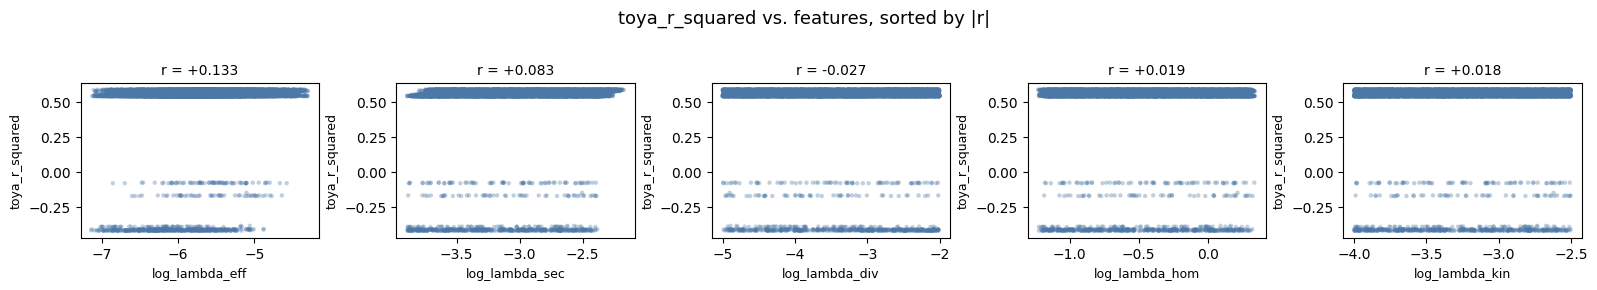

In [37]:
plot_feature_grid(WEIGHT_FEATURES, "toya_r_squared", "toya_r_squared")

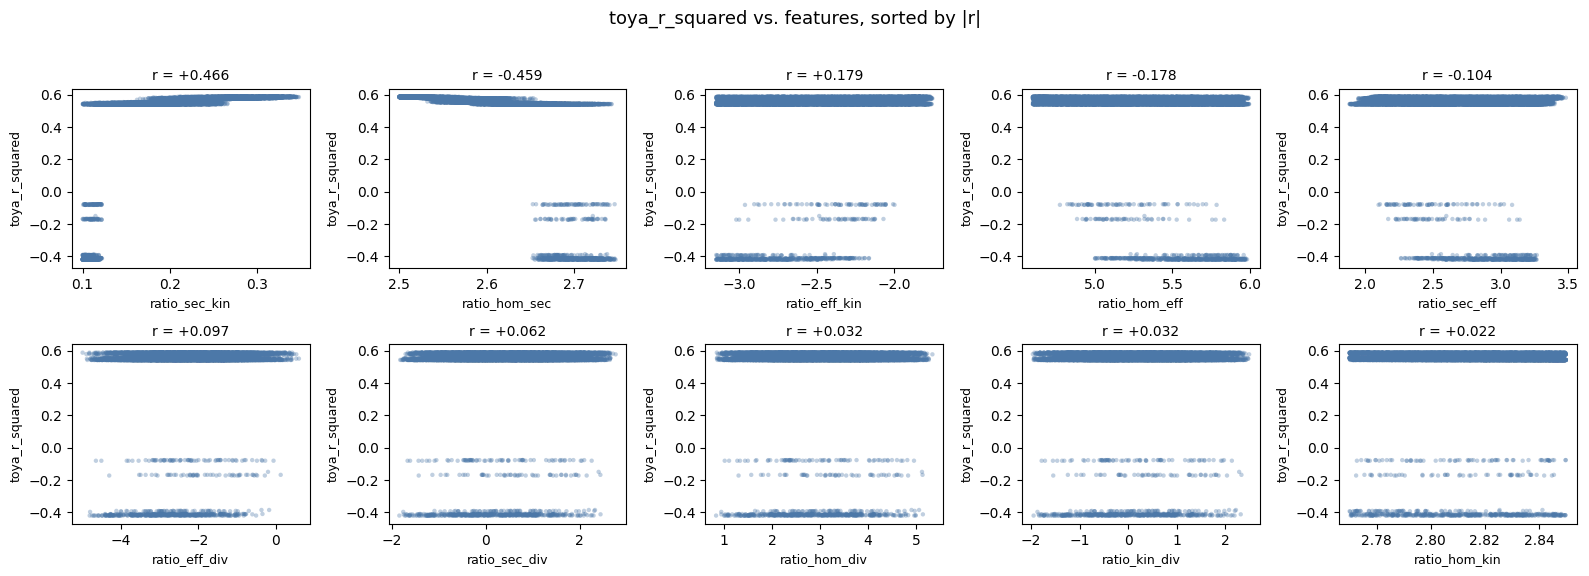

In [38]:
plot_feature_grid(RATIO_FEATURES, "toya_r_squared", "toya_r_squared")

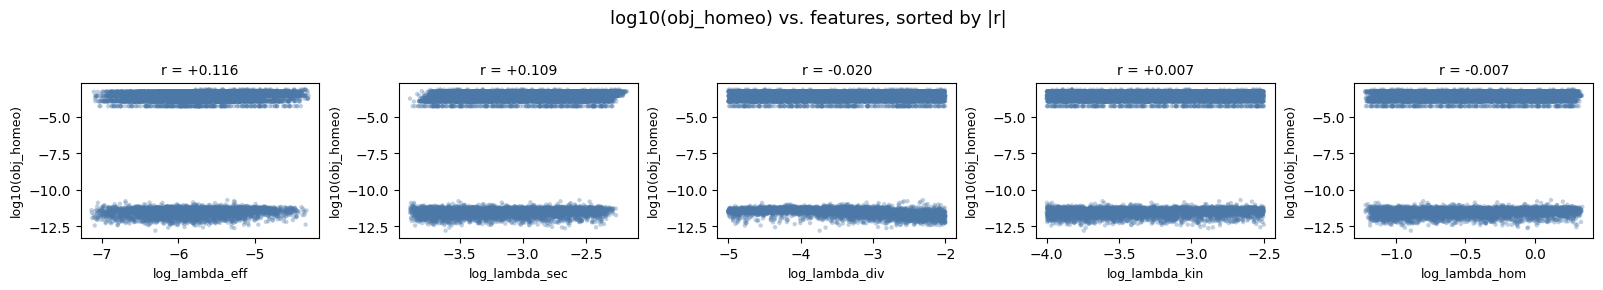

In [39]:
plot_feature_grid(WEIGHT_FEATURES, "log_obj_homeo", "log10(obj_homeo)")

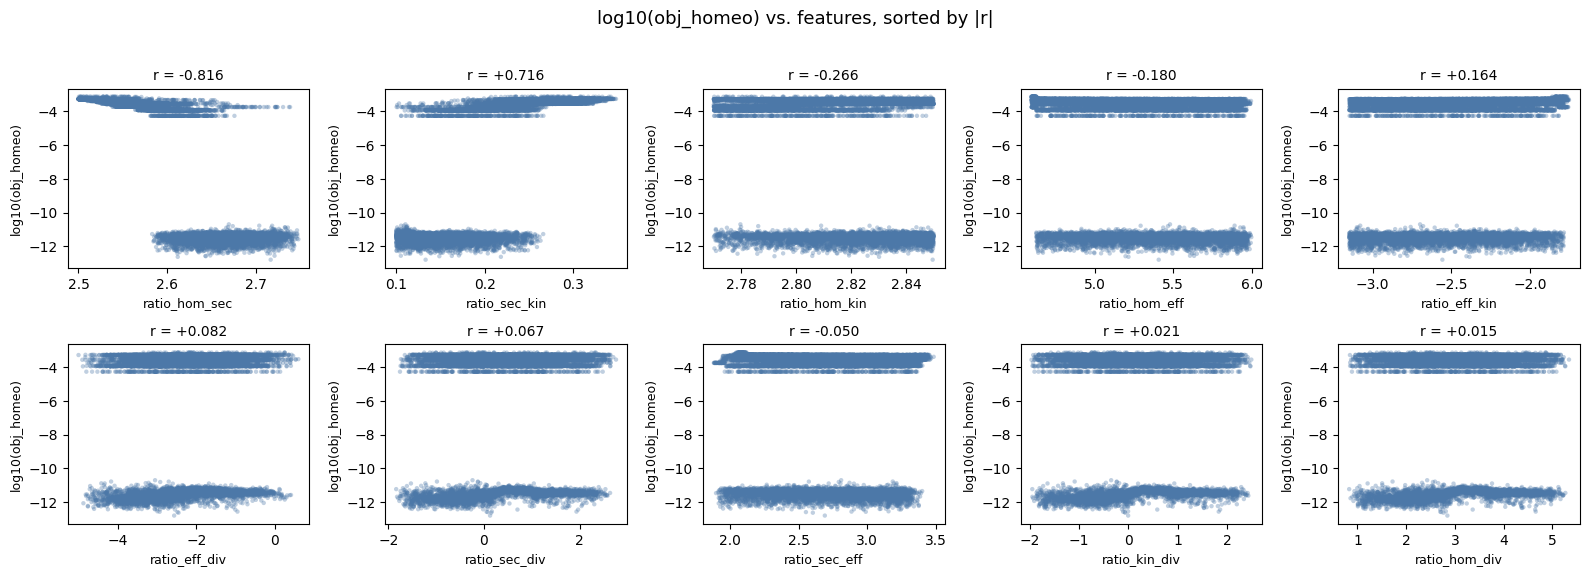

In [40]:
plot_feature_grid(RATIO_FEATURES, "log_obj_homeo", "log10(obj_homeo)")

# Segment regions of interest and anlyze

plot_feature_grid(RATIO_FEATURES, "log_obj_homeo", "log10(obj_homeo)") shows interesting regions of **ratio_hom_eff** and **ratio_hom_kin**. We can segment the data into regions of interest and analyze the distribution of **toya_r_squared** and **log_obj_homeo** in those regions.

In [41]:
df.columns

Index(['lambda_hom', 'lambda_sec', 'lambda_eff', 'lambda_kin', 'lambda_div',
       'fraction_kinetic_target', 'obj_total', 'obj_homeo', 'obj_kin',
       'obj_eff', 'obj_sec', 'obj_div', 'obj_hom_w', 'obj_kin_w', 'obj_eff_w',
       'obj_sec_w', 'obj_div_w', 'toya_pearson_r_squared', 'toya_r_squared',
       'log_lambda_hom', 'log_lambda_sec', 'log_lambda_eff', 'log_lambda_kin',
       'log_lambda_div', 'ratio_hom_sec', 'ratio_hom_eff', 'ratio_hom_kin',
       'ratio_hom_div', 'ratio_sec_eff', 'ratio_sec_kin', 'ratio_sec_div',
       'ratio_eff_kin', 'ratio_eff_div', 'ratio_kin_div', 'log_obj_homeo'],
      dtype='object')

In [42]:
import altair as alt

interval = alt.selection_interval()

tooltip = ["ratio_hom_eff", "ratio_hom_kin", "toya_r_squared", "ratio_hom_sec", "lambda_sec", "lambda_hom", "log_lambda_kin"]

def make_layered_chart(x_field, title, y_field="log_obj_homeo", filter_homeo=False):
    base = alt.Chart(df).mark_circle(size=60, opacity=0.5)
    if filter_homeo:
        base = base.transform_filter(alt.datum.log_obj_homeo < -10)

    # Background: all points, always gray, no interaction needed on this layer
    background = base.encode(
        x=alt.X(x_field),
        y=alt.Y(y_field),
        color=alt.value("lightgray"),
    )

    # Foreground: only points inside the current selection, colored, drawn on top
    foreground = base.encode(
        x=alt.X(x_field),
        y=alt.Y(y_field),
        color=alt.Color(
            "toya_r_squared:Q",
            scale=alt.Scale(scheme="viridis", domain=[0, 1.0]),
            legend=alt.Legend(
                title="R² (Coefficient of Determination)",
                values=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
            ),
        ),
        tooltip=tooltip,
    ).transform_filter(interval)

    return (
        (background + foreground)
        .properties(width=400, height=300, title=title)
        .add_params(interval)
    )

chart_1 = make_layered_chart("ratio_hom_eff", "Interactive Scatter: ratio_hom_eff vs log_obj_homeo")
chart_2 = make_layered_chart("ratio_hom_kin", "Interactive Scatter: ratio_hom_kin vs log_obj_homeo")
chart_3 = make_layered_chart("ratio_hom_sec", "Interactive Scatter: ratio_hom_sec vs log_obj_homeo")
chart_4 = make_layered_chart("ratio_sec_kin", "Interactive Scatter: ratio_sec_kin vs log_obj_homeo")

In [43]:
# --- Plot Distributions of Toya R-square for Selected Points ---
# Define bin edges and labels together so the order stays consistent
bin_labels = ["< 0", "0 – 0.5", "0.5 – 0.6", "0.6 – 0.7", "0.7 – 0.8", "≥ 0.8"]

r2_bin_expr = (
    "datum.toya_r_squared < 0 ? '< 0' : "
    "datum.toya_r_squared < 0.5 ? '0 – 0.5' : "
    "datum.toya_r_squared < 0.6 ? '0.5 – 0.6' : "
    "datum.toya_r_squared < 0.7 ? '0.6 – 0.7' : "
    "datum.toya_r_squared < 0.8 ? '0.7 – 0.8' : "
    "'≥ 0.8'"
)

density = (
    alt.Chart(df)
    .transform_filter(interval)
    .transform_calculate(r2_bin=r2_bin_expr)
    .mark_bar(opacity=0.4)
    .encode(
        x=alt.X("r2_bin:N", title="Toya R-square", sort=bin_labels),
        y=alt.Y("count()", title="Count"),
        tooltip=[alt.Tooltip("r2_bin:N", title="Bin"), alt.Tooltip("count()", title="Count")],
    )
    .properties(title="Distribution of Toya R-square", width=500, height=300)
)

In [44]:
import os
scatter_chart = alt.hconcat(chart_1, chart_2) & alt.hconcat(chart_3, chart_4)
chart = scatter_chart | density
alt.data_transformers.enable("vegafusion")
alt.renderers.enable('browser')
chart.show()

try:
    os.makedirs(f'{PARETO_DIR}/pareto_conditional_analysis', exist_ok=False)
except FileExistsError:
    pass
out = os.path.join(f'{PARETO_DIR}/pareto_conditional_analysis', "ratio_pairwise_analysis_obj_home.html")
chart.save(out)

In [45]:
specs = {
    "y_field": "toya_r_squared",
    "filter_homeo": True,
}
chart_1 = make_layered_chart("ratio_eff_kin", **specs, title="Interactive Scatter: ratio_eff_kin vs toya_r_squared")
chart_2 = make_layered_chart("ratio_sec_kin", **specs, title="Interactive Scatter: ratio_sec_kin vs toya_r_squared")
chart_3 = make_layered_chart("log_lambda_kin", **specs, title="Interactive Scatter: log_lambda_kin vs toya_r_squared")
chart_4 = make_layered_chart("ratio_hom_kin", **specs, title="Interactive Scatter: ratio_hom_kin vs toya_r_squared")



# --- Plot Distributions of Toya R-square for Selected Points ---
# Define bin edges and labels together so the order stays consistent
bin_labels = ["< 0", "0 – 0.5", "0.5 – 0.6", "0.6 – 0.7", "0.7 – 0.8", "≥ 0.8"]

r2_bin_expr = (
    "datum.toya_r_squared < 0 ? '< 0' : "
    "datum.toya_r_squared < 0.5 ? '0 – 0.5' : "
    "datum.toya_r_squared < 0.6 ? '0.5 – 0.6' : "
    "datum.toya_r_squared < 0.7 ? '0.6 – 0.7' : "
    "datum.toya_r_squared < 0.8 ? '0.7 – 0.8' : "
    "'≥ 0.8'"
)

density = (
    alt.Chart(df)
    .transform_filter(interval, alt.datum.log_obj_homeo < -10)
    .transform_calculate(r2_bin=r2_bin_expr)
    .mark_bar(opacity=0.4)
    .encode(
        x=alt.X("r2_bin:N", title="Toya R-square", sort=bin_labels),
        y=alt.Y("count()", title="Count"),
        tooltip=[alt.Tooltip("r2_bin:N", title="Bin"), alt.Tooltip("count()", title="Count")],
    )
    .properties(title="Distribution of Toya R-square", width=500, height=300)
)

scatter_chart = alt.hconcat(chart_1, chart_2) & alt.hconcat(chart_3, chart_4)
chart = scatter_chart | density
alt.data_transformers.enable("vegafusion")
alt.renderers.enable('browser')
chart.show()

out = os.path.join(f'{PARETO_DIR}/pareto_conditional_analysis', "ratio_pairwise_analysis_toya_low_homeo.html")
chart.save(out)

## Summary

**What to look for above:**
- In the RF importance printouts and the combined table, compare `rf_imp_toya_r2`
  vs `rf_imp_log_obj_homeo` for each feature — a feature that's important for one
  target but not the other is a comparatively "clean" lever; a feature important
  for both (especially with opposite-signed `r`) marks a genuine tradeoff axis.
- The ratio grids should show a much cleaner top panel (higher \|r\|) than the raw
  weight grids for `toya_r_squared` — ratios between weights explain Toya fit far
  better than any single weight's magnitude.
- For `log10(obj_homeo)`, `log_lambda_hom` and ratios involving it should dominate,
  since `obj_homeo` is most directly controlled by how much relative weight
  `lambda_hom` gets over everything else.

**Next step:** filter to the joint region (e.g. `obj_homeo < 1e-11` and
`toya_r_squared > 0.5`) to see which weight/ratio combination actually achieves
both simultaneously — the marginal correlations above don't always agree with
what the joint-feasible region looks like.